<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/03.variational-learning-and-kernels/01.loss-and-optimization/02_quantum_loss_parameter_sweep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day19 quantum loss parameter sweep 실습

- Source: Google Drive `Day19/1-1.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


STEP 2. Experiment Setting
Target : 1
Shots : 1000
Theta List : [0.1, 1.0, 2.5]


STEP 3. Quantum Circuit
     ┌─────────┐┌─┐
  q: ┤ Ry(0.1) ├┤M├
     └─────────┘└╥┘
c: 1/════════════╩═
                 0 


STEP 4. Simulator
AerSimulator('aer_simulator')


STEP 5. Single Parameter Test
{'1': 235, '0': 765}


STEP 6. Prediction
P(0) : 0.765
P(1) : 0.235
Prediction : 0.235


STEP 7. Loss
Target : 1
Prediction : 0.235
Loss : 0.585225


STEP 8. Parameter Change
--------------------------------
Theta : 0.1
Counts : {'1': 3, '0': 997}
Prediction : 0.003
Loss : 0.994009


--------------------------------
Theta : 1.0
Counts : {'1': 209, '0': 791}
Prediction : 0.209
Loss : 0.625681
--------------------------------
Theta : 2.5
Counts : {'0': 95, '1': 905}
Prediction : 0.905
Loss : 0.009024999999999995


STEP 9. Result Table
Theta	Prediction	Loss
0.10	0.003		0.9940
1.00	0.209		0.6257
2.50	0.905		0.0090


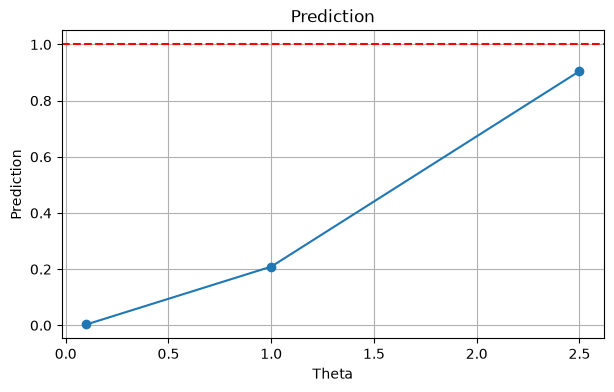

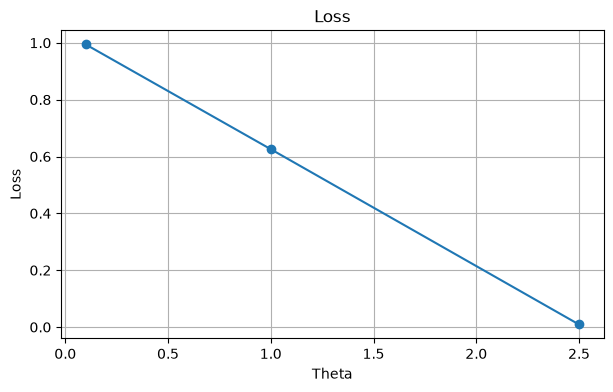



STEP 12. Best Parameter
Best Theta : 2.5
Prediction : 0.905
Loss : 0.009024999999999995


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit import transpile

from qiskit_aer import AerSimulator

print("=" * 70)
print("STEP 2. Experiment Setting")
print("=" * 70)

shots = 1000

target = 1

theta_list = [0.1, 1.0, 2.5]

print("Target :", target)
print("Shots :", shots)
print("Theta List :", theta_list)

print("\n")
print("=" * 70)
print("STEP 3. Quantum Circuit")
print("=" * 70)

theta = theta_list[0]

qc = QuantumCircuit(1,1)

qc.ry(theta,0)

qc.measure(0,0)

print(qc.draw())

print("\n")
print("=" * 70)
print("STEP 4. Simulator")
print("=" * 70)

simulator = AerSimulator()

print(simulator)

print("\n")
print("=" * 70)
print("STEP 5. Single Parameter Test")
print("=" * 70)

theta = 1.0

qc = QuantumCircuit(1,1)

qc.ry(theta,0)

qc.measure(0,0)

compiled = transpile(qc, simulator)

job = simulator.run(
    compiled,
    shots=shots
)

result = job.result()

counts = result.get_counts()

print(counts)

print("\n")
print("=" * 70)
print("STEP 6. Prediction")
print("=" * 70)

count0 = counts.get("0",0)
count1 = counts.get("1",0)

p0 = count0/shots
p1 = count1/shots

prediction = p1

print("P(0) :",p0)
print("P(1) :",p1)

print("Prediction :",prediction)

print("\n")
print("=" * 70)
print("STEP 7. Loss")
print("=" * 70)

loss = (prediction-target)**2

print("Target :",target)

print("Prediction :",prediction)

print("Loss :",loss)



print("\n")
print("=" * 70)
print("STEP 8. Parameter Change")
print("=" * 70)

results = []

for theta in theta_list:

    qc = QuantumCircuit(1,1)

    qc.ry(theta,0)

    qc.measure(0,0)

    compiled = transpile(qc, simulator)

    job = simulator.run(
        compiled,
        shots=shots
    )

    result = job.result()

    counts = result.get_counts()

    p1 = counts.get("1",0)/shots

    prediction = p1

    loss = (prediction-target)**2

    print("--------------------------------")

    print("Theta :",theta)

    print("Counts :",counts)

    print("Prediction :",prediction)

    print("Loss :",loss)

    results.append([
        theta,
        prediction,
        loss
    ])


print("\n")
print("=" * 70)
print("STEP 9. Result Table")
print("=" * 70)

print("Theta\tPrediction\tLoss")

for row in results:

    print(f"{row[0]:.2f}\t{row[1]:.3f}\t\t{row[2]:.4f}")


theta_plot = [r[0] for r in results]
prediction_plot = [r[1] for r in results]

plt.figure(figsize=(7,4))

plt.plot(
    theta_plot,
    prediction_plot,
    marker='o'
)

plt.axhline(
    target,
    linestyle='--',
    color='red'
)

plt.title("Prediction")

plt.xlabel("Theta")

plt.ylabel("Prediction")

plt.grid()

plt.show()



loss_plot = [r[2] for r in results]

plt.figure(figsize=(7,4))

plt.plot(
    theta_plot,
    loss_plot,
    marker='o'
)

plt.title("Loss")

plt.xlabel("Theta")

plt.ylabel("Loss")

plt.grid()

plt.show()


print("\n")
print("=" * 70)
print("STEP 12. Best Parameter")
print("=" * 70)

best = min(
    results,
    key=lambda x:x[2]
)

print("Best Theta :",best[0])

print("Prediction :",best[1])

print("Loss :",best[2])




